In [1]:
from BLEanalysis.old_angleinference import AnglesRejectionSampling
from BLEanalysis.signals import Signals
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import circmean


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# Training data used for angle inference, consists of reading many packets over many rotations of the transmitter at a different
# location to that of the test data. This file was taken at Ponderosa Park, Sheffield, UK
trainingsigs = Signals("../bluetooth_experiments/no rf amp experiments/noamploc2long.log", ['d'], angleOffset = 38)
    
# Helper function to subsample randomly from a set of signal strengths
def randomSampleFromBurstDict(dict, n):
    samples = {}
    samples['transmitter_position'] = dict['transmitter_position']
    samples['rssis'] = []
    samples['angles'] = []
    samples['times'] = []
    # Randomly select unique indices
    
    #rand_indices = np.random.choice(len(dict['rssis']), size=n, replace=False)
    rand_indices = np.linspace(0, len(dict['rssis'])-1, n)
    rand_indices = [int(x) for x in rand_indices]
    
    # We rotate these indecies so we don't always hit near the peak for some particular n of samples
    rotationValue = np.random.randint(0,len(dict['rssis'])-1)
    rand_indices = [((x + rotationValue ) - (len(dict['rssis'])-1)) for x in rand_indices]
    
    #print(rotationValue)
    # Collect samples at those indices
    samples['rssis'] = np.array([dict['rssis'][i] for i in rand_indices])
    samples['angles'] = np.array([dict['angles'][i] for i in rand_indices])
    samples['times'] = np.array([dict['times'][i] for i in rand_indices])

    return samples

# Helper function to calculate error between two angles
def angularDistance(a1, a2):
    diff = abs(a1 - a2) % 360
    return np.abs(min(diff, 360 - diff))

Standardising angles and times (shifting by 38.00 degrees)


Standardising angles and times (shifting by 90.00 degrees)
Transmitter       Number of records
        c                 8315


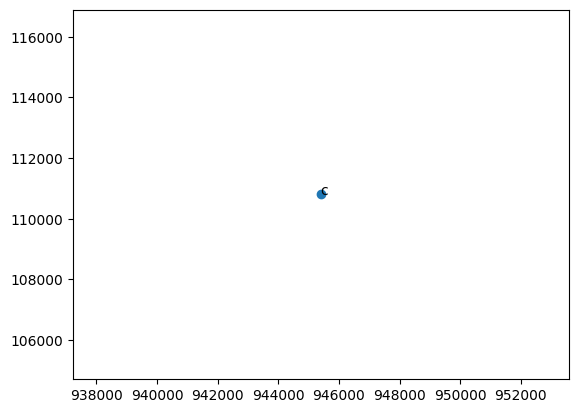

In [3]:
# Load in test data, measured at Common Lane Open Space, Sheffield, UK
testsigs = Signals("../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log",['c'],angleOffset= 90)
testsigs.configureTransmitter('c',0,0,1,1)
testsigs.noramliseTransmitterLocs()
testsigs.summarise(showNormalised = False)

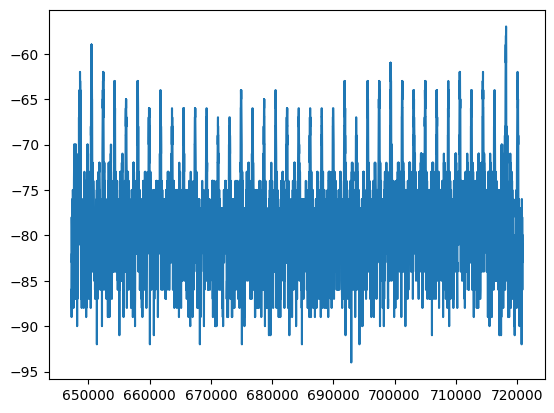

In [4]:
testsigs.data = testsigs.data[250:len(testsigs.data)-40]
plt.plot([i[3] for i in testsigs.data],[i[0] for i in testsigs.data])
plt.show()

In [5]:
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
peaks = []
for b in burst:
    maxind = np.argmax(b['rssis'])
    peaks.append(b['angles'][maxind])

groundTruthAngle = 360 - np.rad2deg(circmean(peaks)) % 360
print("True angle = " + str(groundTruthAngle))

True angle = 266.9461548619557


Let's just subsample one burst and try it on that:

In [43]:
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
i = 10
currentBurst = randomSampleFromBurstDict(burst[i], 25)

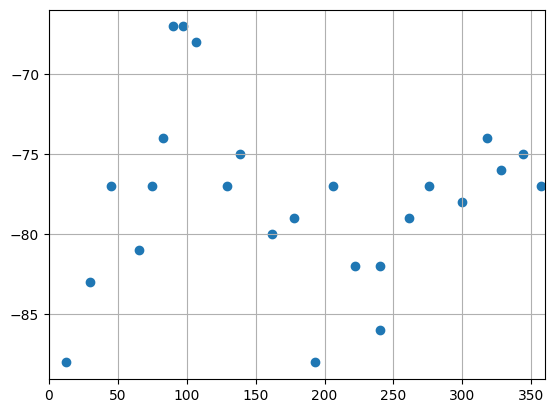

In [44]:
plt.scatter(np.rad2deg(currentBurst['angles']), currentBurst['rssis'])
plt.xlim(0,360)
plt.grid()

In [45]:
angleInference = AnglesRejectionSampling(trainingsigs, usecache = False)

In [46]:
currentTimes = [(x - np.min(currentBurst['times']))/1000 for x in currentBurst['times']]
results = angleInference.infer(np.array(currentTimes),np.array(currentBurst['rssis']),rejection_threshold = 65)

In [47]:
#print(np.mean([np.rad2deg(x) for x in results]))
#results
i = 0
for predangle in results:
    print(predangle)
    print(currentBurst['angles'][i])
    predangle -= currentBurst['angles'][i]
    if predangle < 0:
        predangle += np.pi * 2
    elif predangle > 2*np.pi:
        predangle -= np.pi * 2
    predangle = int(np.rad2deg(predangle))
    print(predangle)
    i += 1

3.490658503988659
4.1887902047863905
320
1.0995574287564276
4.5553093477052
162
0.4014257279586958
4.817108735504349
107
2.775073510670984
5.235987755982989
219
0.3665191429188092
5.550147021341968
63
0.4537856055185257
5.724679946541401
58
2.6179938779914944
6.003932626860494
165
3.1066860685499065
6.230825429619756
181
0.47123889803846897
0.20943951023931956
14
5.619960191421741
0.5235987755982988
292
0.47123889803846897
0.7853981633974483
342
2.6878070480712677
1.1344640137963142
89
5.759586531581287
1.4486232791552935
247
5.375614096142535
1.3089969389957472
233
1.2740903539558606
1.5707963267948966
343


In [18]:
results

array([], dtype=float64)

In [ ]:
results = angleInference.infer(np.array([0,0.1,0.2,0.3,0.4]),np.array([-70,-60,-50,-55,-60]),rejection_threshold = 100)

In [ ]:
print(results)